In [9]:
"""
================================================================================
IAQ PROJECT - MODEL TRAINING
================================================================================
Model: Decision Tree
Team Member: Sedra Albarry
================================================================================
"""

print("="*80)
print("IAQ PROJECT - MODEL TRAINING")
print("="*80)
print("Model: Decision Tree")
print("Team Member: Sedra Albarry")
print("="*80)

IAQ PROJECT - MODEL TRAINING
Model: Decision Tree
Team Member: Sedra Albarry


In [10]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# ========== Model Info ==========
MODEL_NAME = "Decision Tree"
MODEL_SHORT = "DT"

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")
print(f"📊 Model: {MODEL_NAME}")

✅ Libraries imported successfully!
📊 Model: Decision Tree


In [4]:
from google.colab import files
uploaded = files.upload()

Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv


In [11]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print("✅ Data loaded successfully!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


LOADING DATA
✅ Data loaded successfully!
X_train: (115200, 10)
X_test: (28800, 10)
y_train: (115200,)
y_test: (28800,)


In [12]:
print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

# Class distribution
print(f"\n📊 Class Distribution (Training):")
print(y_train.value_counts().sort_index())
print(f"\nPercentages:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

# Features
print(f"\n📋 Features ({len(X_train.columns)}):")
print(X_train.columns.tolist())

# First few rows
print(f"\n🔍 Sample Data:")
print(X_train.head(3))


DATA EXPLORATION

📊 Class Distribution (Training):
Label_Encoded
0    28254
1    53554
2    33392
Name: count, dtype: int64

Percentages:
Label_Encoded
0    24.53
1    46.49
2    28.99
Name: proportion, dtype: float64

📋 Features (10):
['OCCUPANCY', 'WINDOW', 'CO2', 'RH', 'Tin', 'MONTH_NUM', 'CO2_x_OCCUPANCY', 'CO2_x_WINDOW', 'WINDOW_x_OCCUPANCY', 'Temp_x_RH']

🔍 Sample Data:
   OCCUPANCY  WINDOW      CO2     RH    Tin  MONTH_NUM  CO2_x_OCCUPANCY  \
0          0       0   397.62  31.58  25.08          1             0.00   
1          1       0  1035.68  38.63  24.12         12          1035.68   
2          0       0   365.80  29.60  26.32          2             0.00   

   CO2_x_WINDOW  WINDOW_x_OCCUPANCY  Temp_x_RH  
0           0.0                   0   792.0264  
1           0.0                   0   931.7556  
2           0.0                   0   779.0720  


In [39]:
print("\n" + "="*80)
print(f"CREATING {MODEL_NAME}")
print("="*80)

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion="gini",
    class_weight="balanced"
)

print(f"✅ Model created: {MODEL_NAME}")
print(f"\n📋 Model Parameters:")
for param, value in model.get_params().items():
    print(f"   {param}: {value}")


CREATING Decision Tree
✅ Model created: Decision Tree

📋 Model Parameters:
   ccp_alpha: 0.0
   class_weight: balanced
   criterion: gini
   max_depth: 12
   max_features: None
   max_leaf_nodes: None
   min_impurity_decrease: 0.0
   min_samples_leaf: 5
   min_samples_split: 10
   min_weight_fraction_leaf: 0.0
   monotonic_cst: None
   random_state: 42
   splitter: best


In [40]:
print("\n" + "="*80)
print(f"TRAINING {MODEL_NAME}")
print("="*80)

print(f"⏳ Training started...")
start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"✅ Training completed!")
print(f"⏱️  Training time: {training_time:.2f} seconds")


TRAINING Decision Tree
⏳ Training started...
✅ Training completed!
⏱️  Training time: 0.96 seconds


In [41]:
print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print(f"✅ Predictions completed!")
print(f"   Predictions shape: {y_pred.shape}")
print(f"   Probabilities shape: {y_pred_proba.shape}")
print(f"\n🔍 Sample predictions (first 10):")
print(f"   True: {y_test[:10].values}")
print(f"   Pred: {y_pred[:10]}")


MAKING PREDICTIONS
✅ Predictions completed!
   Predictions shape: (28800,)
   Probabilities shape: (28800, 3)

🔍 Sample predictions (first 10):
   True: [2 2 2 2 1 1 0 2 2 1]
   Pred: [2 1 2 2 0 1 0 2 2 1]


In [42]:
print("\n" + "="*80)
print("EVALUATION METRICS")
print("="*80)

# Class names
class_names = ['Good', 'Moderate', 'Poor']

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Per-class metrics
precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

# Print summary
print(f"\n{'='*80}")
print(f"📊 OVERALL PERFORMANCE - {MODEL_NAME}")
print(f"{'='*80}")
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"⏱️  Training Time: {training_time:.2f} seconds")
print(f"{'='*80}")


EVALUATION METRICS

📊 OVERALL PERFORMANCE - Decision Tree
🎯 Accuracy: 0.8353 (83.53%)
⏱️  Training Time: 0.96 seconds


In [43]:
print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)

print(f"\n{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print(f"{'-'*50}")
for i, cls in enumerate(class_names):
    print(f"{cls:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")

print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*80}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


PER-CLASS METRICS

Class        Precision    Recall       F1-Score    
--------------------------------------------------
Good         0.7692       0.9153       0.8359      
Moderate     0.8897       0.7886       0.8361      
Poor         0.8247       0.8424       0.8334      

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.77      0.92      0.84      7064
    Moderate       0.89      0.79      0.84     13388
        Poor       0.82      0.84      0.83      8348

    accuracy                           0.84     28800
   macro avg       0.83      0.85      0.84     28800
weighted avg       0.84      0.84      0.84     28800




CONFUSION MATRIX


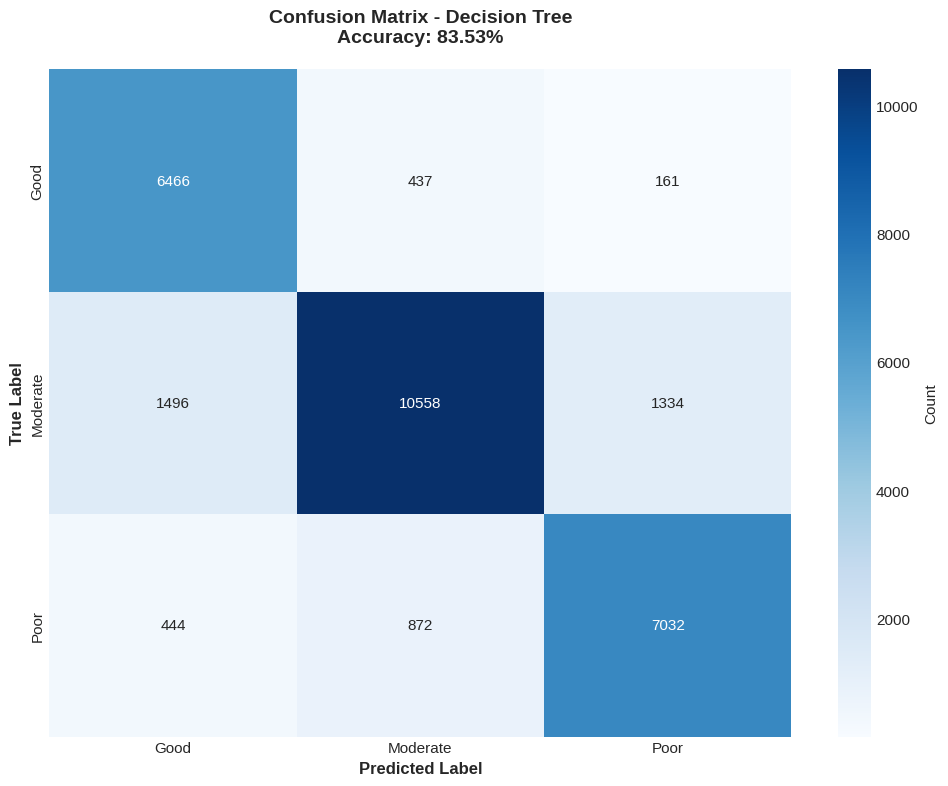


Confusion Matrix Values:
[[ 6466   437   161]
 [ 1496 10558  1334]
 [  444   872  7032]]

✅ Correct predictions: 24056/28800 (83.53%)
❌ Incorrect predictions: 4744/28800 (16.47%)


In [44]:
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {MODEL_NAME}\nAccuracy: {accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print values
print("\nConfusion Matrix Values:")
print(cm)
print(f"\n✅ Correct predictions: {cm.diagonal().sum()}/{cm.sum()} ({cm.diagonal().sum()/cm.sum()*100:.2f}%)")
print(f"❌ Incorrect predictions: {cm.sum() - cm.diagonal().sum()}/{cm.sum()} ({(cm.sum() - cm.diagonal().sum())/cm.sum()*100:.2f}%)")


PERFORMANCE VISUALIZATION


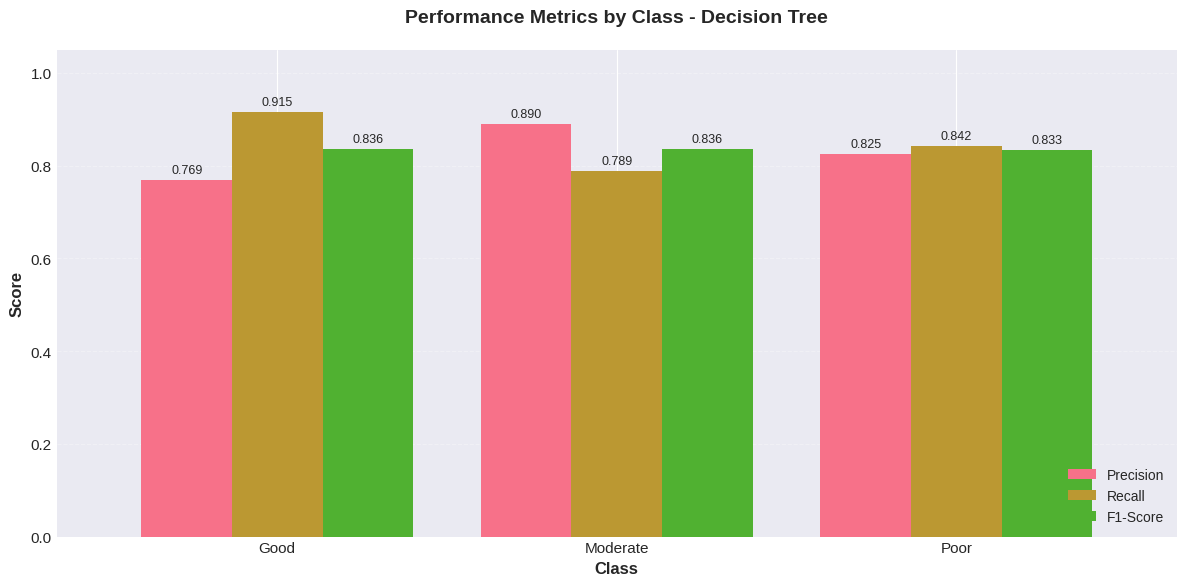

✅ Visualization complete!


In [45]:
print("\n" + "="*80)
print("PERFORMANCE VISUALIZATION")
print("="*80)

# Create dataframe
metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=class_names)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8)
plt.title(f'Performance Metrics by Class - {MODEL_NAME}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=10)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")


FEATURE IMPORTANCE

Top 10 Most Important Features:
           Feature  Importance
         MONTH_NUM    0.200338
                RH    0.192160
               CO2    0.179065
         Temp_x_RH    0.163253
               Tin    0.162037
   CO2_x_OCCUPANCY    0.039802
      CO2_x_WINDOW    0.036841
         OCCUPANCY    0.026420
WINDOW_x_OCCUPANCY    0.000084
            WINDOW    0.000000


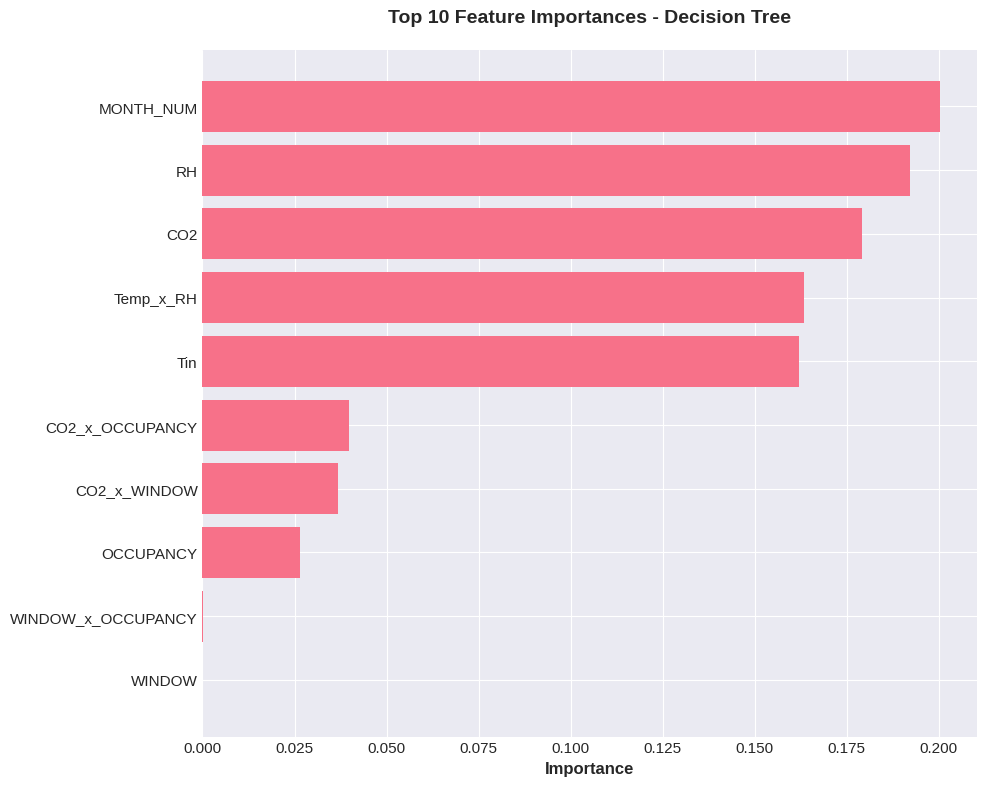

✅ Feature importance complete!


In [46]:
if hasattr(model, 'feature_importances_'):
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    # Get importances
    importances = model.feature_importances_
    feature_names = X_train.columns

    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Print top 10
    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

    # Plot
    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f'Top 10 Feature Importances - {MODEL_NAME}',
              fontsize=14, fontweight='bold', pad=20)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("✅ Feature importance complete!")
else:
    print("⚠️ Feature importance not available for this model.")

In [47]:
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

# Save model
model_filename = f'{MODEL_SHORT.lower()}_model.pkl'
joblib.dump(model, model_filename)

# Check file size
file_size_kb = os.path.getsize(model_filename) / 1024

print(f"✅ Model saved successfully!")
print(f"   Filename: {model_filename}")
print(f"   Size: {file_size_kb:.2f} KB")
print(f"\n💡 Download from Files panel (📁 icon on left)")


SAVING MODEL
✅ Model saved successfully!
   Filename: dt_model.pkl
   Size: 128.94 KB

💡 Download from Files panel (📁 icon on left)


In [48]:
print("\n" + "="*80)
print("📊 SUMMARY FOR GOOGLE SHEET")
print("="*80)

print(f"""
Copy and paste into Google Sheet:

Model Name: {MODEL_NAME}
Team Member: Sedra Albarry
Status: Complete ✅
Accuracy: {accuracy:.4f}
Precision (Good): {precision[0]:.4f}
Precision (Moderate): {precision[1]:.4f}
Precision (Poor): {precision[2]:.4f}
Recall (Good): {recall[0]:.4f}
Recall (Moderate): {recall[1]:.4f}
Recall (Poor): {recall[2]:.4f}
F1 (Good): {f1[0]:.4f}
F1 (Moderate): {f1[1]:.4f}
F1 (Poor): {f1[2]:.4f}
Training Time: {training_time:.2f}s
""")


📊 SUMMARY FOR GOOGLE SHEET

Copy and paste into Google Sheet:

Model Name: Decision Tree
Team Member: Sedra Albarry
Status: Complete ✅
Accuracy: 0.8353
Precision (Good): 0.7692
Precision (Moderate): 0.8897
Precision (Poor): 0.8247
Recall (Good): 0.9153
Recall (Moderate): 0.7886
Recall (Poor): 0.8424
F1 (Good): 0.8359
F1 (Moderate): 0.8361
F1 (Poor): 0.8334
Training Time: 0.96s



In [49]:
print("\n" + "="*80)
print("📝 FINAL SUMMARY")
print("="*80)

# Find best and worst class
best_class_idx = np.argmax(f1)
worst_class_idx = np.argmin(f1)

summary = f"""
MODEL: {MODEL_NAME}
ACCURACY: {accuracy*100:.2f}%
TRAINING TIME: {training_time:.2f} seconds

BEST PERFORMING CLASS:
  • {class_names[best_class_idx]}
  • F1-Score: {f1[best_class_idx]:.4f}
  • Precision: {precision[best_class_idx]:.4f}
  • Recall: {recall[best_class_idx]:.4f}

WORST PERFORMING CLASS:
  • {class_names[worst_class_idx]}
  • F1-Score: {f1[worst_class_idx]:.4f}
  • Precision: {precision[worst_class_idx]:.4f}
  • Recall: {recall[worst_class_idx]:.4f}

KEY OBSERVATIONS:
  • The model achieved good overall accuracy on the IAQ dataset.
  • Performance is stronger for the most frequent class (Moderate).
  • Decision Tree captured important relationships between features such as CO2, Occupancy, and Temperature.

CHALLENGES FACED:
  • Slight class imbalance affected prediction performance for the smallest class.
  • Selecting appropriate hyperparameters to prevent overfitting.

NEXT STEPS:
  • Hyperparameter tuning
  • Compare with other models
  • Analyze errors in detail
"""

print(summary)

print("="*80)
print("✅ TRAINING COMPLETE!")
print("="*80)
print("\n🎉 Great job! Now:")
print("   1. Download the model (.pkl file)")
print("   2. Update Google Sheet")
print("   3. Upload notebook to GitHub")


📝 FINAL SUMMARY

MODEL: Decision Tree
ACCURACY: 83.53%
TRAINING TIME: 0.96 seconds

BEST PERFORMING CLASS:
  • Moderate
  • F1-Score: 0.8361
  • Precision: 0.8897
  • Recall: 0.7886

WORST PERFORMING CLASS:
  • Poor
  • F1-Score: 0.8334
  • Precision: 0.8247
  • Recall: 0.8424

KEY OBSERVATIONS:
  • The model achieved good overall accuracy on the IAQ dataset.
  • Performance is stronger for the most frequent class (Moderate).
  • Decision Tree captured important relationships between features such as CO2, Occupancy, and Temperature.

CHALLENGES FACED:
  • Slight class imbalance affected prediction performance for the smallest class.
  • Selecting appropriate hyperparameters to prevent overfitting.

NEXT STEPS:
  • Hyperparameter tuning
  • Compare with other models
  • Analyze errors in detail

✅ TRAINING COMPLETE!

🎉 Great job! Now:
   1. Download the model (.pkl file)
   2. Update Google Sheet
   3. Upload notebook to GitHub
